# Salary Prediction

### Importing Libraries

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Data Preprocessing

###  Data Understanding

In [51]:
df = pd.read_csv("Salary Data.csv")


In [52]:
X.columns


Index(['Age', 'Gender', 'Years of Experience', 'Education Level_Bachelor's',
       'Education Level_Master's', 'Education Level_PhD'],
      dtype='object')

In [53]:
df.shape

(375, 6)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


### Missing Value Handling

In [55]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [56]:
df = df.dropna()

### Duplicate Removal

In [57]:
print(df.duplicated().sum())

49


In [58]:
df.drop_duplicates(inplace=True)

In [59]:
df.shape

(324, 6)

In [60]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

### Outlier Detection


<Axes: ylabel='Age'>

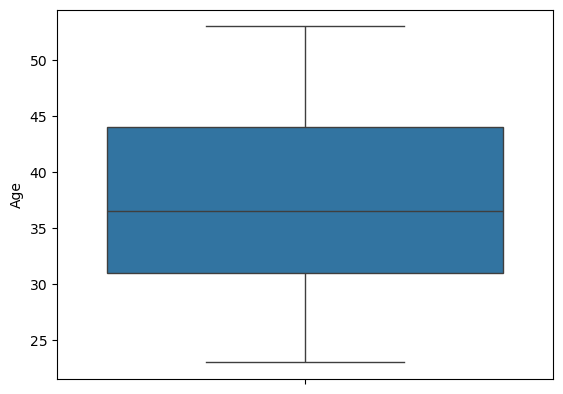

In [61]:
sns.boxplot(y="Age", data=df)

### Feature Encoding

In [62]:
df["Gender"] = df["Gender"].map({"Male":0,"Female":1})

In [63]:
df = pd.get_dummies(df, columns=["Education Level"])
df.head()

,Age,Gender,Job Title,Years of Experience,Salary,Education Level_Bachelor's,Education Level_Master's,Education Level_PhD
0,32.0,0,Software Engineer,5.0,90000.0,True,False,False
1,28.0,1,Data Analyst,3.0,65000.0,False,True,False
2,45.0,0,Senior Manager,15.0,150000.0,False,False,True
3,36.0,1,Sales Associate,7.0,60000.0,True,False,False
4,52.0,0,Director,20.0,200000.0,False,True,False


### Visualisation

<Axes: xlabel='Age', ylabel='Salary'>

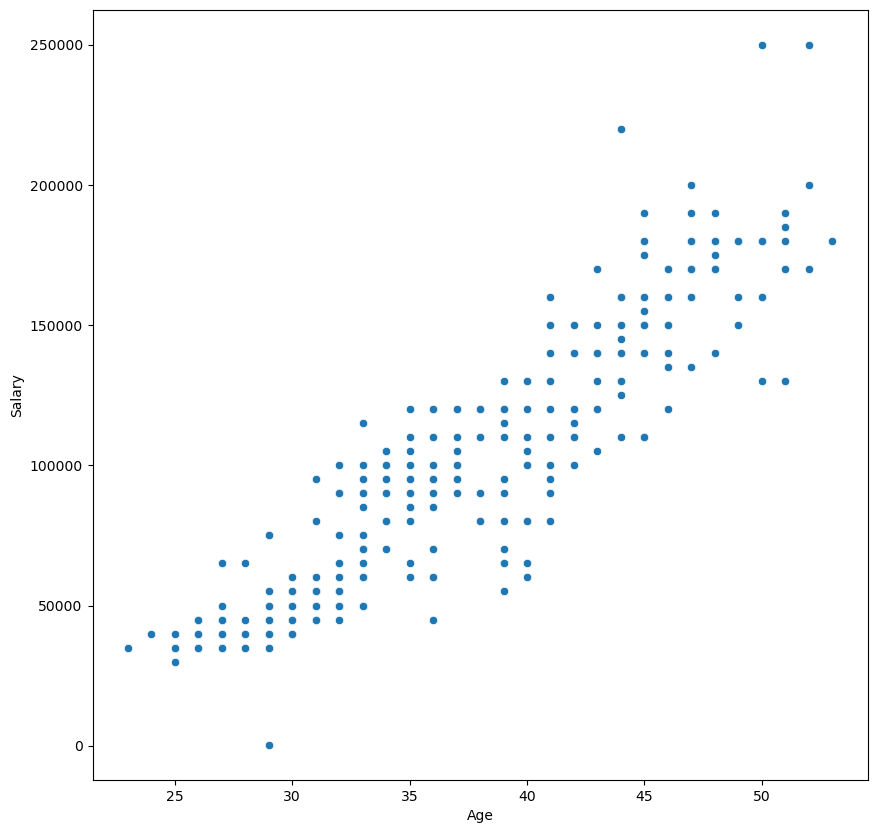

In [64]:
plt.figure(figsize=(10,10))
sns.scatterplot(x="Age", y="Salary", data=df)

### Train a Model

In [65]:
X = df.drop(["Salary","Job Title"], axis=1)
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Predict and Evaluate

In [66]:
# Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0)
}

# Train, Predict, Evaluate
for name, model in models.items():

    # Training
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"\n{name}")
    print("-" * 30)
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.2f}")
    print(f"MSE      : {mse:.2f}")
    print(f"RMSE     : {rmse:.2f}")


Linear Regression
------------------------------
R² Score : 0.8922
MAE      : 10469.74
MSE      : 203743396.72
RMSE     : 14273.87

Ridge
------------------------------
R² Score : 0.8924
MAE      : 10416.79
MSE      : 203251531.20
RMSE     : 14256.63

Lasso
------------------------------
R² Score : 0.8922
MAE      : 10468.75
MSE      : 203740849.04
RMSE     : 14273.78


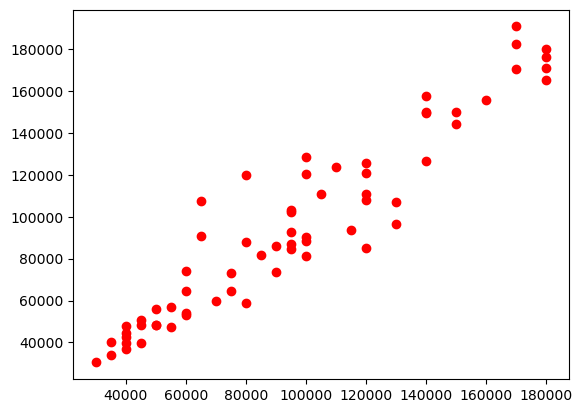

In [67]:
plt.scatter(y_test, y_pred, color="red")
plt.show()

In [68]:
new_employee = [[30.0, 1, 2.0, False, False, True]]


salary = model.predict(new_employee)

print("Predicted Salary:", salary)

Predicted Salary: [70664.35705367]


C:\Users\ninga\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [69]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [70]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bag.fit(X_train, y_train)

,estimator,DecisionTreeRegressor()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [72]:
dt_pred = dt.predict(X_test)

bag_pred = bag.predict(X_test)

In [73]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Decision Tree")

print("MAE:", mean_absolute_error(y_test, dt_pred))

print("R2:", r2_score(y_test, dt_pred))

print()

print("Bagging")

print("MAE:", mean_absolute_error(y_test, bag_pred))

print("R2:", r2_score(y_test, bag_pred))

Decision Tree
MAE: 9889.743589743588
R2: 0.8791934116949616

Bagging
MAE: 10443.605380943844
R2: 0.8799859266204997
